<a href="https://colab.research.google.com/github/HanifFaishalH/PCVK25_3F_15/blob/master/Week5_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praktikum 5 - Histogram, Histogram Equalization, Dithering

Nama : Hanif Faishal Hilmi

Kelas : TI-3F

NIM : 2341720116

## Percobaan D1 HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Import library yang akan digunakan

In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

3. Membuat histogram citra

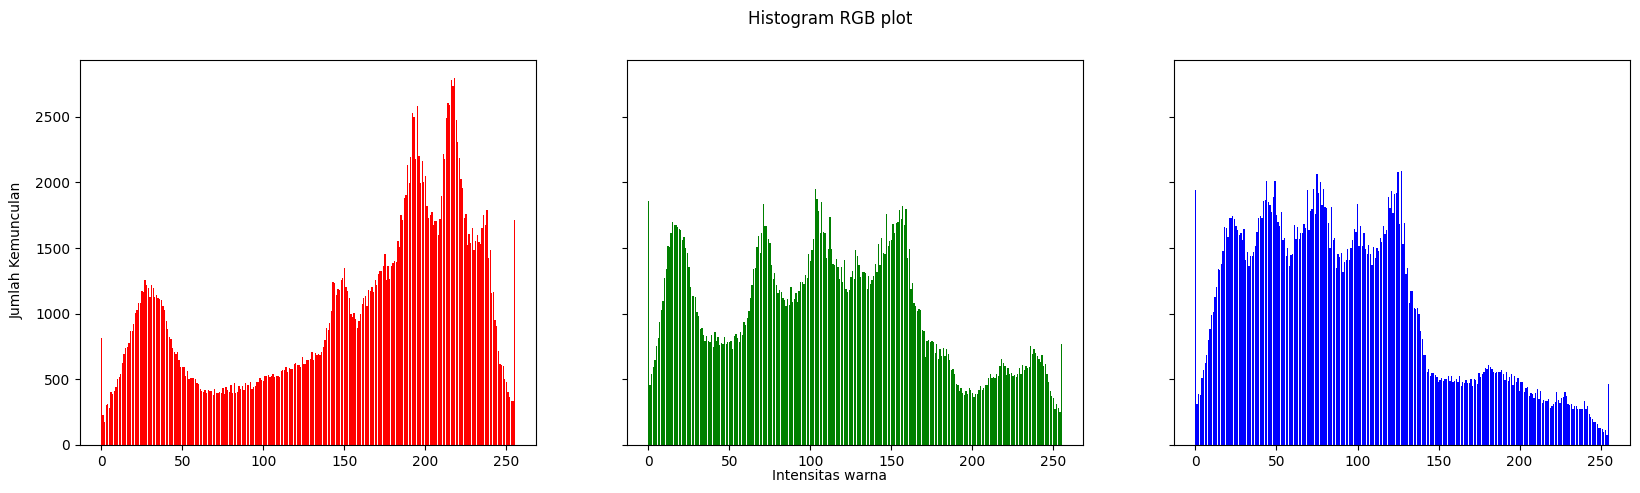

In [3]:
img = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height):
  for x in range(0,width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

## PERTANYAAN PRAKTIKUM D1

1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh
NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

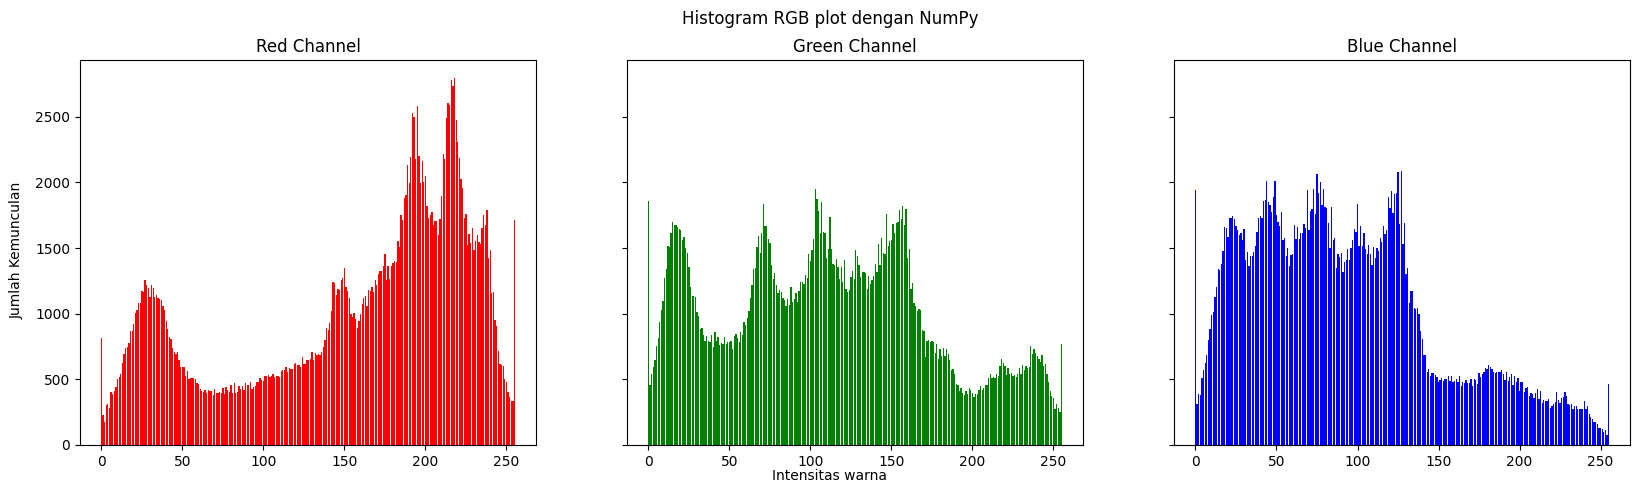

In [4]:
red_hist, red_bin = np.histogram(img[:,:,0].ravel(), bins=256, range=[0,256])
green_hist, green_bin = np.histogram(img[:,:,1].ravel(), bins=256, range=[0,256])
blue_hist, blue_bin = np.histogram(img[:,:,2].ravel(), bins=256, range=[0,256])

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot dengan NumPy')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')

axs[0].bar(names, red_hist, color='red')
axs[0].set_title('Red Channel')

axs[1].bar(names, green_hist, color='green')
axs[1].set_title('Green Channel')

axs[2].bar(names, blue_hist, color='blue')
axs[2].set_title('Blue Channel')
plt.show()

Output yang ditampilkan dengan menggunakan histogram library numpy sama seperti di percobaan.

2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.
Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah.


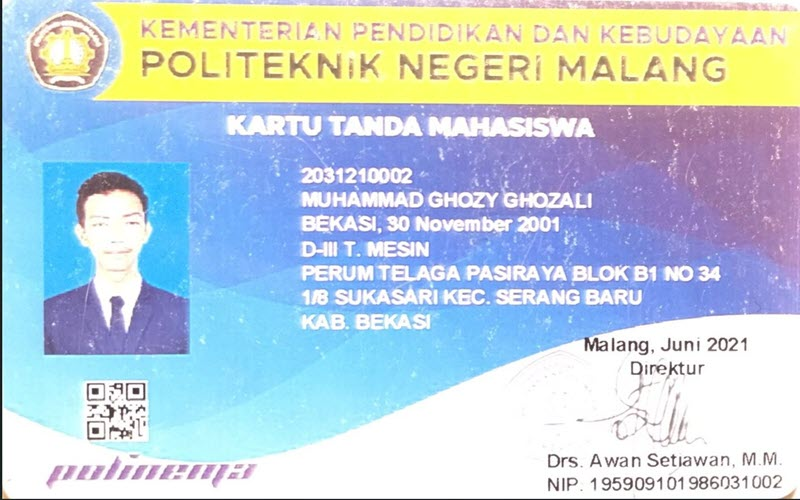

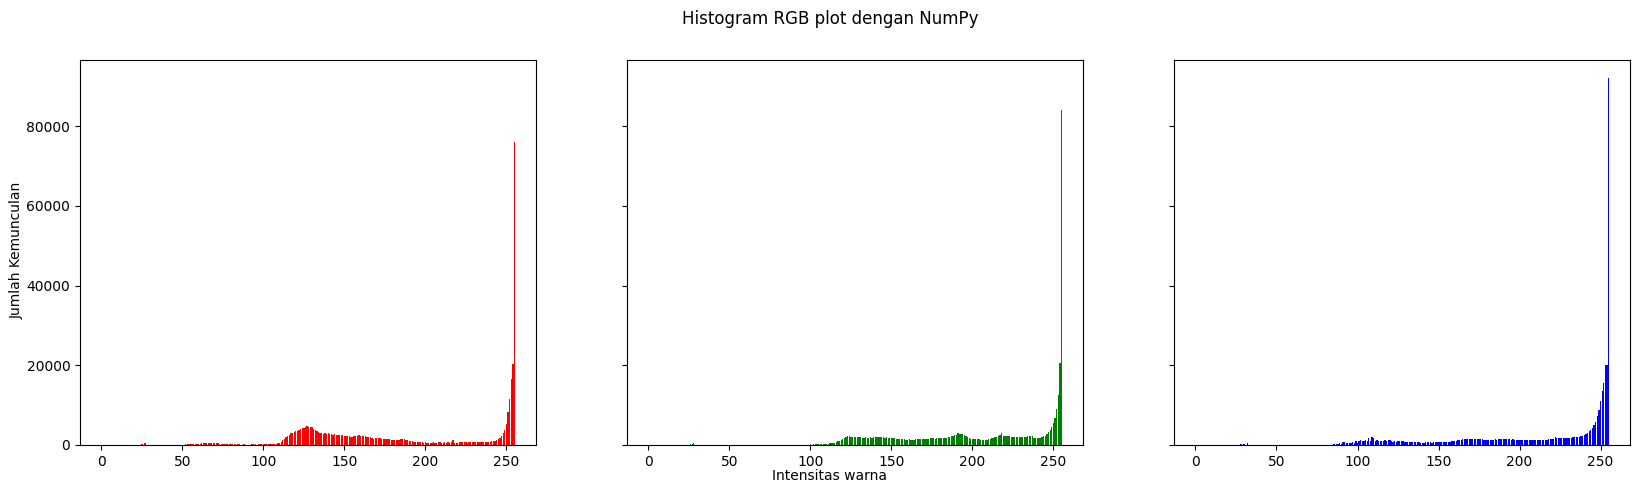

In [16]:
ktm = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/KTMLama.jpg')
ktm_rgb = cv.cvtColor(ktm, cv.COLOR_BGR2RGB)

cv2_imshow(ktm)

height, width, depth = np.shape(ktm_rgb)

ktm_red_hist, ktm_red_bin = np.histogram(ktm_rgb[:,:,0].ravel(), bins=256, range=[0,256])
ktm_green_hist, ktm_green_bin = np.histogram(ktm_rgb[:,:,1].ravel(), bins=256, range=[0,256])
ktm_blue_hist, ktm_blue_bin = np.histogram(ktm_rgb[:,:,2].ravel(), bins=256, range=[0,256])

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot dengan NumPy')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')
axs[0].bar(names, ktm_red_hist, color='red')
axs[1].bar(names, ktm_green_hist, color='green')
axs[2].bar(names, ktm_blue_hist, color='blue')
plt.show()

Dari grafik tersebut. Distribusi piksel mayoritas dari channel berada di sisi kanan karena citra didominasi warna terang. Makanya, citra tersebut cenderung terang.